# Ecommerce
Ask yourself 15 analystical questions that you belive will help the managers in decision making

# Analytical Questions

1. What are the top-selling products based on OrderValue?
2. Which country contributes the most to sales revenue?
3. How does the sales trend vary month-to-month?
4. What is the average order size (in terms of quantity or value) across different categories?
5. Are there peak times during the day when most orders are placed?
6. Which categories have the highest unit price on average?
7. What's the distribution of order values?
8. Is there any correlation between UnitPrice and Quantity?
9. How frequently do the top customers purchase?
10. What proportion of sales is accounted for by the top customers?
11. Are there any seasonal trends noticeable in the order data?
12. What is the return rate of the orders?
13. How do sales compare across different major and minor categories?
14. Is there a significant difference in sales between new and returning customers, if that data is available?
15. How does the total OrderValue distribute across various time periods (e.g., quarterly, yearly, etc.)?


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv('ecommerce.csv')

In [3]:
df

,InvoiceNo,UnitPrice,OrderValue,Quantit,Country,InvoiceDate,InvoiceTime,Year-Month,Major Category,Minor Category,Description
0,549185,0.85,10.20,12,United Kingdom,7/4/11,09:35,2011-04,Clothes,Tops,PACK OF 20 NAPKINS PANTRY DESIGN
1,576381,2.95,35.40,12,United Kingdom,15/11/11,09:26,2011-11,Clothes,Shoes,NATURAL SLATE HEART CHALKBOARD
2,551192,1.25,20.00,16,United Kingdom,27/4/11,10:54,2011-04,Kitchen,Cutlery,36 PENCILS TUBE SKULLS
3,573553,7.46,7.46,1,United Kingdom,31/10/11,13:48,2011-10,Garden,Turf,SET 6 SCHOOL MILK BOTTLES IN CRATE
4,539436,2.51,2.51,1,United Kingdom,17/12/10,14:49,2010-12,Garden,Hoses,FINE WICKER HEART
...,...,...,...,...,...,...,...,...,...,...,...
695,564087,1.25,20.00,16,Hong Kong,23/8/11,09:38,2011-08,Clothes,Tops,WOOD STAMP SET THANK YOU
696,553148,0.55,13.20,24,Hong Kong,13/5/11,14:09,2011-05,Garden,Hoses,GREEN POLKADOT BOWL
697,564087,4.95,29.70,6,Hong Kong,23/8/11,09:38,2011-08,Garden,Rakes,TOY TIDY SPACEBOY
698,553148,0.85,27.20,32,Hong Kong,13/5/11,14:09,2011-05,Kitchen,Cooking Knives,RED RETROSPOT CHILDRENS UMBRELLA


In [4]:
df.describe()

,InvoiceNo,UnitPrice,OrderValue,Quantit
count,700.000000,700.000000,700.000000,700.000000
mean,559180.801429,3.367086,31.978471,20.865714
std,13246.185339,8.280695,63.658083,63.867322
min,536370.000000,0.120000,0.290000,1.000000
25%,547501.000000,1.250000,8.290000,3.000000
50%,559327.500000,1.950000,15.600000,8.000000
75%,570672.000000,3.750000,25.272500,16.000000
max,581587.000000,202.420000,633.600000,1152.000000


In [5]:
# Rename columns
df.rename(columns={'Quantit': 'Quantity'}, inplace=True)


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   InvoiceNo       700 non-null    int64  
 1   UnitPrice       700 non-null    float64
 2   OrderValue      700 non-null    float64
 3   Quantity        700 non-null    int64  
 4   Country         700 non-null    object 
 5    InvoiceDate    700 non-null    object 
 6   InvoiceTime     700 non-null    object 
 7   Year-Month      700 non-null    object 
 8   Major Category  700 non-null    object 
 9   Minor Category  700 non-null    object 
 10  Description     700 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 60.3+ KB


In [13]:
df.describe(include='object')

,Country,InvoiceDate,InvoiceTime,Year-Month,Major Category,Minor Category,Description
count,700,700,700,700,700,700,700
unique,5,240,341,13,4,17,398
top,United Kingdom,13/5/11,14:09,2011-11,Garden,Tops,POSTAGE
freq,300,17,20,106,189,63,11


In [14]:
df.head() # Display the first few rows of the dataframe to understand its structure and contents. 

,InvoiceNo,UnitPrice,OrderValue,Quantity,Country,InvoiceDate,InvoiceTime,Year-Month,Major Category,Minor Category,Description,InvoiceDate,Month
0,549185,0.85,10.20,12,United Kingdom,7/4/11,09:35,2011-04,Clothes,Tops,PACK OF 20 NAPKINS PANTRY DESIGN,2011-04-07,2011-04
1,576381,2.95,35.40,12,United Kingdom,15/11/11,09:26,2011-11,Clothes,Shoes,NATURAL SLATE HEART CHALKBOARD,2011-11-15,2011-11
2,551192,1.25,20.00,16,United Kingdom,27/4/11,10:54,2011-04,Kitchen,Cutlery,36 PENCILS TUBE SKULLS,2011-04-27,2011-04
3,573553,7.46,7.46,1,United Kingdom,31/10/11,13:48,2011-10,Garden,Turf,SET 6 SCHOOL MILK BOTTLES IN CRATE,2011-10-31,2011-10
4,539436,2.51,2.51,1,United Kingdom,17/12/10,14:49,2010-12,Garden,Hoses,FINE WICKER HEART,2010-12-17,2010-12


In [19]:
#numers of products
df['Description'].nunique() # Count the number of unique products in the dataset.

398

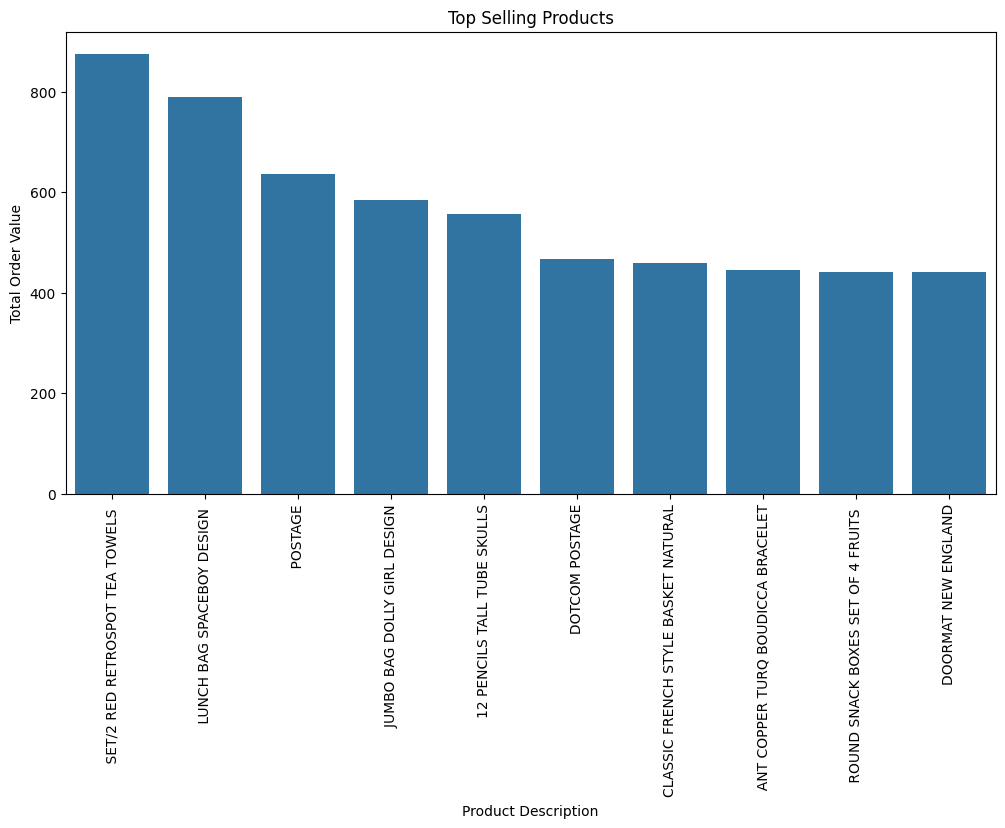

In [22]:
# Analyze top-selling products based on OrderValue

top_selling_products = df.groupby('Description')['OrderValue'].sum().sort_values(ascending=False)

# Display the top 5 selling product
top_selling_products.head(5)
# visualize the top-selling products
plt.figure(figsize=(12, 6))
sns.barplot(x=top_selling_products.head(10).index, y=top_selling_products.head(10).values)
plt.xticks(rotation=90)
plt.title('Top Selling Products')
plt.xlabel('Product Description')
plt.ylabel('Total Order Value')
plt.show()

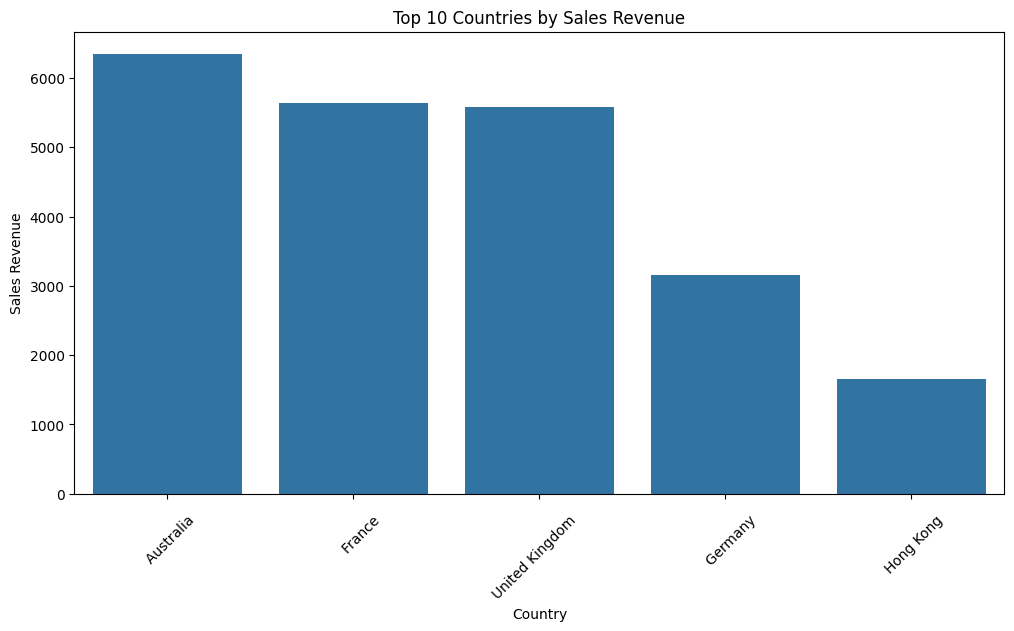

In [21]:
# Analyze which country contributes the most to sales revenue

country_sales = df.groupby('Country')['OrderValue'].sum().sort_values(ascending=False)
country_sales.head() 
# Plotting the top 10 countries by sales revenue
import matplotlib.pyplot as plt
import seaborn as sns   
plt.figure(figsize=(12, 6))
sns.barplot(x=country_sales.head(10).index, y=country_sales.head(10).values)
plt.xticks(rotation=45)
plt.title('Top 10 Countries by Sales Revenue')
plt.xlabel('Country')
plt.ylabel('Sales Revenue')
plt.show()

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Month', ylabel='Total Order Value'>

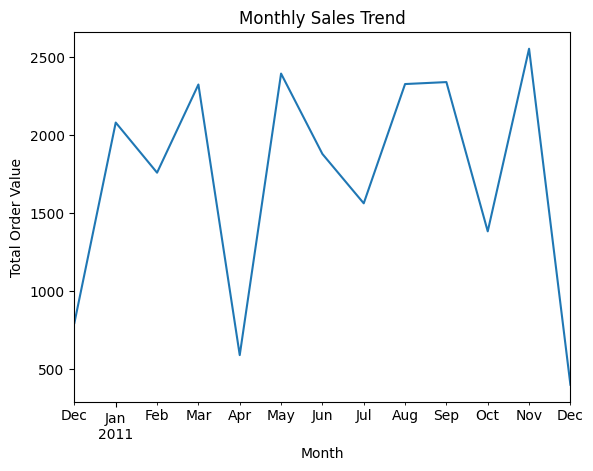

In [23]:
# Analyze the sales trend month-to-month

# Convert ' InvoiceDate' to datetime format and extract month and year for trend analysis
df['InvoiceDate'] = pd.to_datetime(df[' InvoiceDate'].str.strip(), format='%d/%m/%y')
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# Calculate monthly sales trend
monthly_sales_trend = df.groupby('Month')['OrderValue'].sum()
monthly_sales_trend.plot(kind='line', title='Monthly Sales Trend', ylabel='Total Order Value') 

In [27]:
df.head() # Display the first few rows of the dataframe to understand its structure and contents.

,InvoiceNo,UnitPrice,OrderValue,Quantity,Country,InvoiceDate,InvoiceTime,Year-Month,Major Category,Minor Category,Description,InvoiceDate,Month
0,549185,0.85,10.20,12,United Kingdom,7/4/11,09:35,2011-04,Clothes,Tops,PACK OF 20 NAPKINS PANTRY DESIGN,2011-04-07,2011-04
1,576381,2.95,35.40,12,United Kingdom,15/11/11,09:26,2011-11,Clothes,Shoes,NATURAL SLATE HEART CHALKBOARD,2011-11-15,2011-11
2,551192,1.25,20.00,16,United Kingdom,27/4/11,10:54,2011-04,Kitchen,Cutlery,36 PENCILS TUBE SKULLS,2011-04-27,2011-04
3,573553,7.46,7.46,1,United Kingdom,31/10/11,13:48,2011-10,Garden,Turf,SET 6 SCHOOL MILK BOTTLES IN CRATE,2011-10-31,2011-10
4,539436,2.51,2.51,1,United Kingdom,17/12/10,14:49,2010-12,Garden,Hoses,FINE WICKER HEART,2010-12-17,2010-12


In [30]:
#find numbers of categories
df['Major Category'].nunique() # Count the number of unique categories in the dataset.

4

In [31]:
# Calculate the average order size in terms of quantity and value across different major categories

average_order_size = df.groupby('Major Category')[['Quantity', 'OrderValue']].mean()
average_order_size 

,Quantity,OrderValue
Major Category,,
Garden,26.021164,31.958095
Clothes,18.568182,28.127102
Kitchen,21.348837,37.255233
Household,16.858896,30.592515


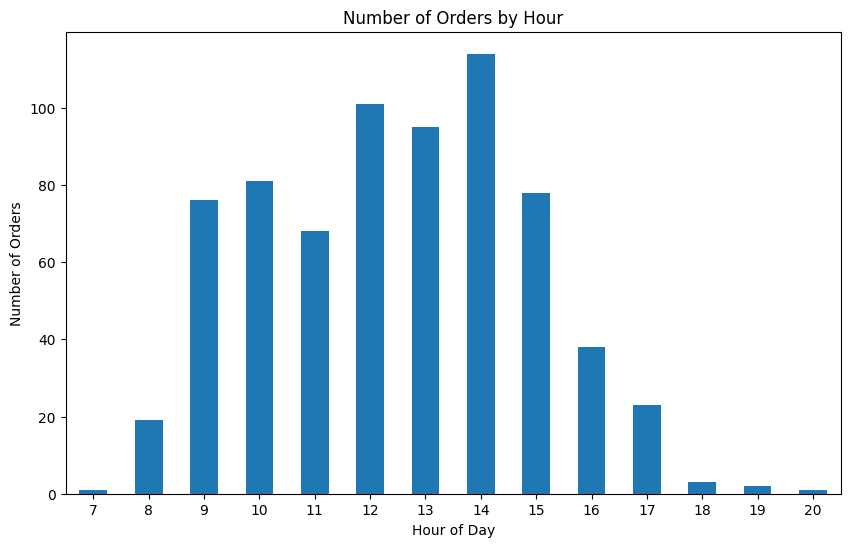

In [32]:
# Determine peak times during the day when most orders are placed
# Convert 'InvoiceTime' to a datetime object to extract the hour
# Assuming that the 'InvoiceTime' is in 24-hour format
# Strip any extra spaces first if needed
df['InvoiceTime'] = df['InvoiceTime'].str.strip()
df['InvoiceHour'] = pd.to_datetime(df['InvoiceTime'], format='%H:%M').dt.hour

# Aggregate the number of orders per hour
daily_peak_times = df.groupby('InvoiceHour').size()

# Plotting the distribution of orders by hour
plt.figure(figsize=(10, 6))
daily_peak_times.plot(kind='bar')
plt.title('Number of Orders by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show() 

In [33]:
# Determine which categories have the highest unit price on average
category_avg_unit_price = df.groupby('Major Category')['UnitPrice'].mean().sort_values(ascending=False)

# Display the results
category_avg_unit_price.head() 

Major Category
Household      4.237178
  Kitchen      3.297849
   Garden      3.026878
  Clothes      2.994261
Name: UnitPrice, dtype: float64

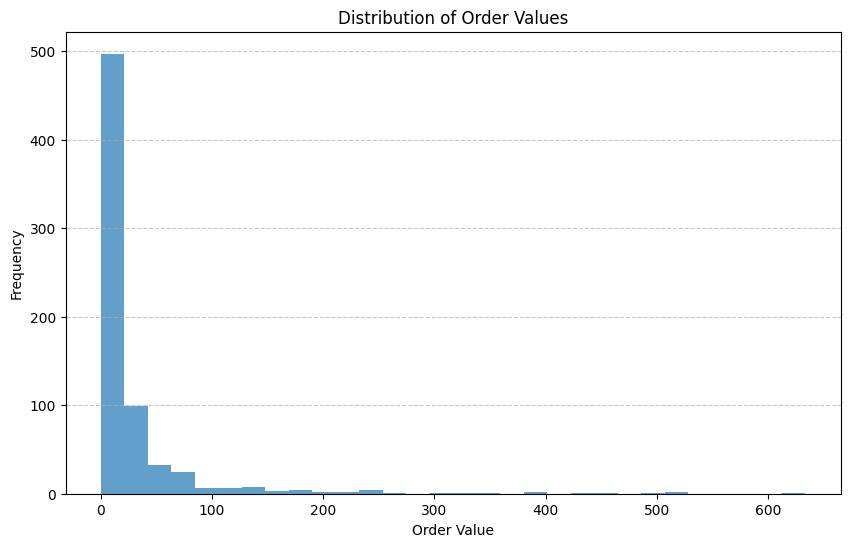

In [34]:
# Visualize the distribution of order values
plt.figure(figsize=(10, 6))
df['OrderValue'].plot(kind='hist', bins=30, alpha=0.7)
plt.title('Distribution of Order Values')
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show() 

Correlation between UnitPrice and Quantity: -0.07248141002483184


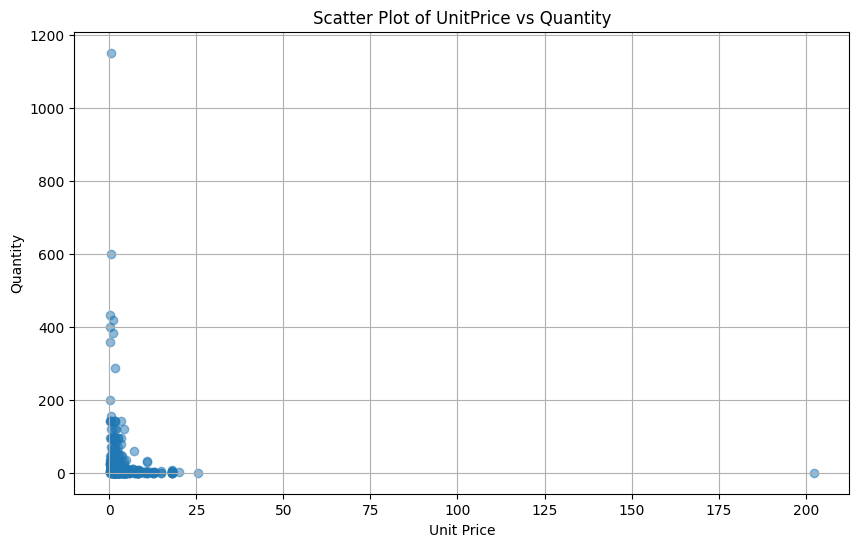

In [38]:
# Evaluate correlation between UnitPrice and Quantity
correlation_coefficient = df['UnitPrice'].corr(df['Quantity'])
print(f"Correlation between UnitPrice and Quantity: {correlation_coefficient}")

# Visualizing the correlation
plt.figure(figsize=(10, 6))
plt.scatter(df['UnitPrice'], df['Quantity'], alpha=0.5)
plt.title('Scatter Plot of UnitPrice vs Quantity')
plt.xlabel('Unit Price')
plt.ylabel('Quantity')
plt.grid(True)
plt.show()

In [40]:
# Analyze frequency of purchases by top customers

# Correct the column name for grouping to match the DataFrame
invoice_column_name = 'InvoiceNo  '  # Adjusted for actual column name format

# Determine top customers based on total OrderValue
top_customers = df.groupby(invoice_column_name)['OrderValue'].sum().nlargest(5)

# Display the number of purchases made by each top customer
purchase_frequency = df[df[invoice_column_name].isin(top_customers.index)].groupby(invoice_column_name).size()

# Display results
purchase_frequency 

InvoiceNo  
541975     8
545475     5
556917     5
564087    13
565145     1
dtype: int64

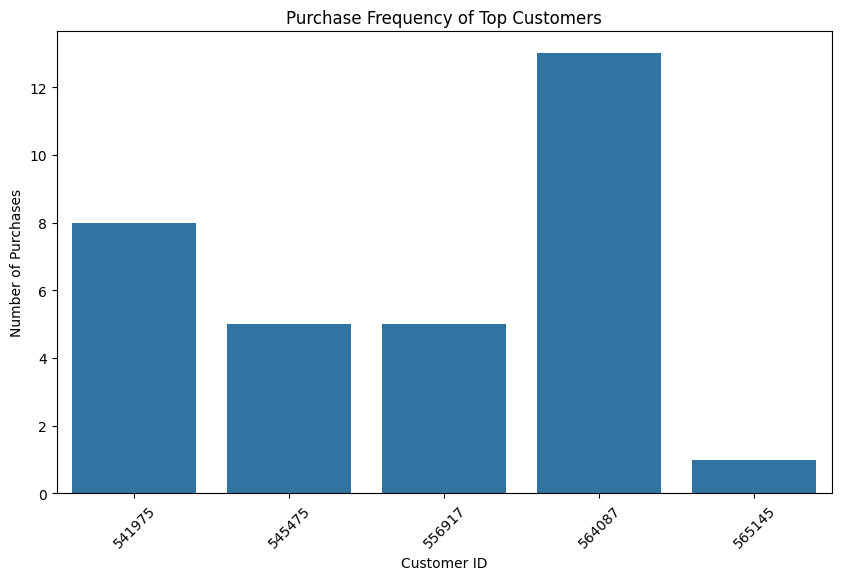

In [41]:
# Visualize the purchase frequency of top customers
plt.figure(figsize=(10, 6))
sns.barplot(x=purchase_frequency.index, y=purchase_frequency.values)
plt.title('Purchase Frequency of Top Customers')
plt.xlabel('Customer ID')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.show()

In [42]:
# Determine the proportion of sales accounted for by the top customers

# Calculate the total OrderValue for the entire dataset
total_sales_value = df['OrderValue'].sum()

# Calculate the total OrderValue for the top customers identified earlier
top_customers_sales_value = top_customers.sum()

# Calculate the proportion of sales that top customers represent
proportion_of_sales = top_customers_sales_value / total_sales_value

# Display the result
proportion_of_sales 

np.float64(0.1721470650120416)

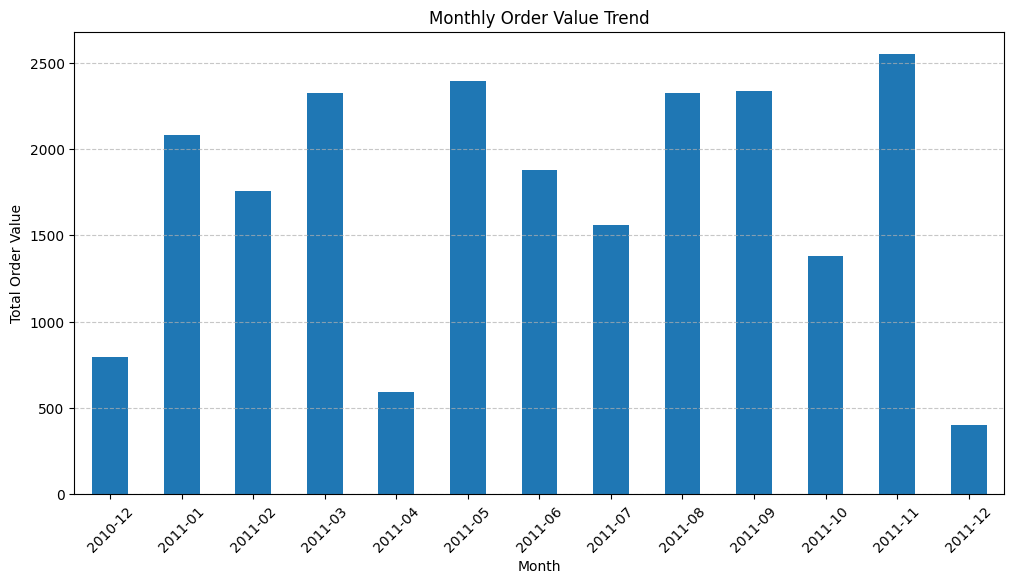

In [43]:
# Analyze seasonal trends in order data

# Group by month and summarize total OrderValue per month
monthly_trends = df.groupby(df['InvoiceDate'].dt.to_period('M'))['OrderValue'].sum()

# Plot the monthly trends to visualize potential seasonal patterns
plt.figure(figsize=(12, 6))
monthly_trends.plot(kind='bar')
plt.title('Monthly Order Value Trend')
plt.xlabel('Month')
plt.ylabel('Total Order Value')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show() 

In [46]:
# Analyze the return rate of the orders

# Check for negative quantities which often indicate returns
returned_orders = df[df['Quantity'] < 0]

# Calculate the return rate
return_rate = len(returned_orders) / len(df)

# Display the return rate
return_rate 

0.0

In [47]:
# Analyze sales across different major and minor categories

# Group by major and minor category and summarize total OrderValue
category_sales = df.groupby(['Major Category', 'Minor Category'])['OrderValue'].sum().sort_values(ascending=False)

# Display the top sales by category combination
category_sales.head(10) 

Major Category  Minor Category
  Clothes           Hats          2056.95
   Garden          Seeds          1903.46
  Clothes           Tops          1760.37
  Kitchen         Scales          1691.79
   Garden          Hoses          1647.73
Household           Rugs          1588.42
   Garden           Turf          1552.74
Household       Curtains          1418.03
  Kitchen          Bowls          1227.39
                  Plates          1148.67
Name: OrderValue, dtype: float64

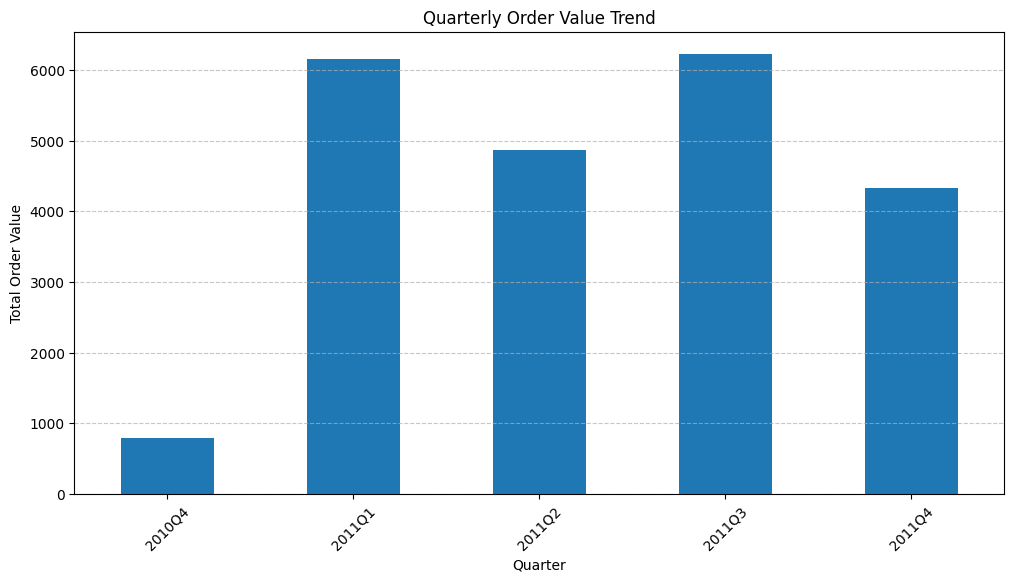

In [49]:
# Analyze distribution of OrderValue across quarters

# Convert 'InvoiceDate' to a quarterly period and group by it
quarterly_trends = df.groupby(df['InvoiceDate'].dt.to_period('Q'))['OrderValue'].sum()

# Plot the quarterly order value trends
plt.figure(figsize=(12, 6))
quarterly_trends.plot(kind='bar')
plt.title('Quarterly Order Value Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Order Value')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show() 